# 7.1 Describing an Atomic Structure

In [1]:
from ecp.style import header, use_style

use_style()
header(
    volume="Volume VII — Data and Descriptors",
    number="7.1",
    title="Describing an Atomic Structure",
    blurb="Before a machine can learn anything about a structure, the structure has to "
    "be turned into numbers — and the obvious numbers, the atomic coordinates, are the "
    "wrong ones. We build descriptors that are blind to the things physics is blind to, "
    "and then find out what they are blind to that physics is not.",
    difficulty="advanced",
    estimate="90–120 min",
    source="FS 2023 · Lecture 10 (machine learning for atomistic systems)",
)

<ECP header: 2900 chars of HTML>

## Notebook overview

Every method in this course so far has taken a structure and returned a number: an
energy, a force, a band gap. Machine learning proposes to shortcut the expensive part
by *fitting* that map from many examples. But a fit needs its input as a fixed-length
vector of numbers, and the obvious choice — the list of atomic coordinates — is a
catastrophe. Translate the system, rotate it, or simply relabel the atoms, and the
coordinate vector changes completely while every physical property stays exactly the
same. A model trained on coordinates would have to learn those symmetries from data,
spending its capacity rediscovering facts we already know.

The fix is a **descriptor**: a function of the structure that is invariant to
translation, rotation and permutation by construction. This notebook builds one from
scratch — the **atom-centred symmetry functions** of Behler and Parrinello
{cite}`behler2007` — verifies its invariance to machine precision, and then asks the
sharper question: what does it fail to distinguish? The answer turns out to be
specific and instructive. Radial functions alone cannot tell face-centred cubic from
hexagonal close packed, *provably*, because within the first two neighbour shells the
two stackings have identical sets of interatomic distances. Adding angular functions
is supposed to fix that, and in the standard form it silently does not, for a reason
worth knowing.

> **Provenance.** This notebook develops **Lecture 10** of the course (machine
> learning for atomistic systems), an exercise **designed by the author (Raymond
> Amador)** to restore a lecture the original exercise set announced but never
> delivered. Unlike most of this course it uses no committed calculation: every
> structure is built here from its lattice definition, so the numbers can be
> re-derived from scratch. The full course credit is in the footer.

> **Reading a validation.** Each task closes with a check against an independent
> fact: that a symmetry operation leaves the descriptor unchanged to machine
> precision, that two lattices with identical shells give identical radial
> descriptors, that angular functions separate what radial ones cannot. A ✗ flags a
> mismatch; a ✓ is strong evidence, not proof.

> **Scope.** We build symmetry functions, not a fitted potential — the descriptor is
> the subject here, and [§7.2](dimensionality-reduction.ipynb) takes the descriptors this notebook produces
> and asks how to visualise and sample them. Structures are perfect and rattled
> lattices rather than trajectory snapshots, so that the shell structure is exact and
> the failures are provable rather than statistical.

## Theory in brief

### What a descriptor has to be blind to

The energy of an isolated system is unchanged by three operations, so any input to a
model of the energy should be unchanged by them too:

- **Translation.** Moving every atom by the same vector changes nothing physical.
- **Rotation.** So does rigidly rotating the whole system.
- **Permutation.** Two atoms of the same element are indistinguishable; swapping
  their labels is not a physical change at all.

Cartesian coordinates satisfy none of these. Interatomic *distances* satisfy the
first two immediately, and the third if we only ever use them in sums over
neighbours, which is the design that follows.

### Atom-centred symmetry functions

Behler and Parrinello {cite}`behler2007` describe the environment of each atom $i$
separately, as a vector of sums over its neighbours. Every sum is cut off smoothly at
a radius $R_c$, so that atoms entering and leaving the environment do not make the
descriptor jump:

```{math}
:label: eq-bp-cutoff
f_c(r) = \begin{cases}
  \tfrac12\left[\cos\!\left(\pi r / R_c\right) + 1\right], & r < R_c,\\
  0, & r \ge R_c.
\end{cases}
```

The **radial** functions place a Gaussian at a chosen distance $R_s$ and ask how much
neighbour density sits there. Varying the width $\eta$ and the centre $R_s$ across a
set of functions samples the radial distribution at different resolutions:

```{math}
:label: eq-bp-g2
G_i^{2} = \sum_{j \ne i} e^{-\eta\,(r_{ij} - R_s)^2}\, f_c(r_{ij}).
```

Radial functions can only ever see the *multiset of distances* from atom $i$. Two
environments with the same distances are identical to every $G^2$, no matter how many
are used — which is exactly the trap Exercise 3 walks into. To see more, the descriptor
has to look at **angles**, summing over pairs of neighbours $(j,k)$ with $\theta_{jik}$
the angle they subtend at $i$:

```{math}
:label: eq-bp-g4
G_i^{4} = 2^{1-\zeta} \sum_{j \ne i}\sum_{k > j}
  \left(1 + \lambda \cos\theta_{jik}\right)^{\zeta}
  e^{-\eta\left(r_{ij}^2 + r_{ik}^2 + r_{jk}^2\right)}
  f_c(r_{ij})\, f_c(r_{ik})\, f_c(r_{jk}).
```

Here $\lambda = \pm 1$ shifts the peak of the angular factor between $\theta = 0$ and
$\theta = \pi$, and $\zeta$ sharpens it: large $\zeta$ resolves fine angular structure,
small $\zeta$ blurs it. The exponential and cutoff factors involve $r_{jk}$, the
distance between the two *neighbours* — an apparently innocent choice that Exercise 4
shows is anything but. Behler's alternative drops it {cite}`behler2011`:

```{math}
:label: eq-bp-g5
G_i^{5} = 2^{1-\zeta} \sum_{j \ne i}\sum_{k > j}
  \left(1 + \lambda \cos\theta_{jik}\right)^{\zeta}
  e^{-\eta\left(r_{ij}^2 + r_{ik}^2\right)}
  f_c(r_{ij})\, f_c(r_{ik}).
```

Symmetry functions are one descriptor family among several. The **smooth overlap of
atomic positions** (SOAP) {cite}`bartok2013` takes a different route to the same
requirements: it smears each neighbour into a Gaussian density, expands that density
in radial functions and spherical harmonics, and builds rotationally invariant
combinations of the coefficients. It is systematically improvable in a way a
hand-chosen set of symmetry functions is not, at a higher cost.

---
## Setup

The Setup below holds this notebook's instruments — nothing you are asked to build.
The descriptors themselves are the subject of the notebook and are built in the
exercises. It is collapsed so the building stays yours; expand it whenever you want
the details.

<!-- setup-policy: v2 -->

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from ase import Atoms
from ase.build import bulk, fcc111

from ecp import validate

INK, AMBER, SOFT = "#16213e", "#c0851a", "#46506b"

# instrument: the lattices. Every phase is copper and every lattice constant is chosen
# to put the NEAREST NEIGHBOUR at the same distance, so that comparing two phases is a
# comparison of how the shells are arranged and not of how dense the two metals are.
# Comparing, say, Cu-fcc against Mg-hcp would mostly measure the density difference
# between copper and magnesium, and would answer a question nobody asked.
NN = 2.5527  # data: Cu nearest-neighbour distance in Å, from a = 3.61 Å (fcc)
A_FCC = NN * np.sqrt(2.0)
A_HCP, C_HCP = NN, NN * np.sqrt(8.0 / 3.0)  # ideal c/a keeps the 12 neighbours equal
A_BCC = 2.0 * NN / np.sqrt(3.0)  # bcc nearest neighbour is the body diagonal, a√3/2

_hcp_cell = Atoms(
    "Cu2",
    scaled_positions=[[0.0, 0.0, 0.0], [1 / 3, 2 / 3, 0.5]],
    cell=[
        [A_HCP, 0.0, 0.0],
        [-A_HCP / 2, A_HCP * np.sqrt(3) / 2, 0.0],
        [0.0, 0.0, C_HCP],
    ],
    pbc=True,
)

LATTICES = {
    "fcc": bulk("Cu", "fcc", a=A_FCC, cubic=True) * (4, 4, 4),
    "hcp": _hcp_cell * (6, 6, 4),
    "bcc": bulk("Cu", "bcc", a=A_BCC, cubic=True) * (5, 5, 5),
}
SLAB = fcc111("Cu", size=(6, 6, 8), a=A_FCC, vacuum=12.0)
PHASES = ("fcc", "hcp", "bcc")


RC_FIRST_SHELL = 2.9  # Å: encloses the twelve nearest neighbours of these lattices


def neighbours(pos, i, cell=None, rc=6.0):
    """Vectors and distances to the neighbours of atom ``i`` within ``rc``.

    Uses the minimum-image convention when a cell is supplied, which is exact here
    because every cell edge is more than twice the largest cutoff used.

    Parameters
    ----------
    pos : numpy.ndarray
        Atomic positions, shape (n_atoms, 3), in Å.
    i : int
        Index of the central atom.
    cell : numpy.ndarray, optional
        Row-wise cell vectors, shape (3, 3). ``None`` treats the system as isolated.
    rc : float, optional
        Cutoff radius in Å.

    Returns
    -------
    tuple of numpy.ndarray
        ``(vectors, distances)``: the displacement vectors from atom ``i`` to each
        neighbour inside the cutoff, shape (n_neighbours, 3), and their lengths.
    """
    d = pos - pos[i]
    if cell is not None:
        frac = np.linalg.solve(np.asarray(cell).T, d.T).T
        frac -= np.round(frac)
        d = frac @ np.asarray(cell)
    r = np.linalg.norm(d, axis=1)
    keep = (r > 1e-8) & (r < rc)
    return d[keep], r[keep]


def shells(pos, i, cell=None, rc=6.0, decimals=3):
    """The neighbour shells of atom ``i`` as ``(distance, count)`` pairs.

    Parameters
    ----------
    pos, i, cell, rc
        As for :func:`neighbours`.
    decimals : int, optional
        Rounding applied before grouping distances into shells.

    Returns
    -------
    tuple of numpy.ndarray
        ``(distances, counts)``, sorted by distance.
    """
    _, r = neighbours(pos, i, cell, rc)
    return np.unique(np.round(r, decimals), return_counts=True)


def cell_of(atoms):
    """Row-wise cell vectors of an ASE object as a plain array."""
    return np.array(atoms.get_cell())


def random_rotation(gen):
    """A uniformly distributed proper rotation matrix, shape (3, 3).

    Built by QR-factorising a Gaussian matrix, whose Q is Haar-distributed on the
    orthogonal group once the sign convention of R's diagonal is fixed; the final
    determinant check discards the reflections.

    Parameters
    ----------
    gen : numpy.random.Generator
        Source of randomness.

    Returns
    -------
    numpy.ndarray
        A rotation matrix with determinant +1.
    """
    q, r = np.linalg.qr(gen.normal(size=(3, 3)))
    q = q * np.sign(np.diag(r))
    if np.linalg.det(q) < 0:
        q[:, 0] *= -1.0
    return q

In [3]:
# A compact renderer for a local environment: the central atom, its neighbours, and the
# bonds to them, drawn in an orthographic projection with painter-sorted depth. Kept out
# of the exercises because drawing an environment is not the same skill as describing
# one.
from matplotlib.patches import Circle  # noqa: E402


def draw_environment(ax, vecs, title="", rc=None, elev=0.35):
    """Draw a central atom and its neighbour shell, sorted back-to-front."""
    c, s = np.cos(elev), np.sin(elev)
    proj = np.array([[1.0, 0.0, 0.0], [0.0, c, -s]])
    depth = np.array([0.0, *(vecs @ np.array([0.0, s, c]))])
    pts = np.vstack([[0.0, 0.0, 0.0], vecs]) @ proj.T
    order = np.argsort(depth)
    for k in order:
        if k > 0:
            ax.plot(
                [0, pts[k, 0]], [0, pts[k, 1]], color=SOFT, lw=0.8, zorder=1, alpha=0.5
            )
    for k in order:
        col = AMBER if k == 0 else INK
        ax.add_patch(
            Circle(
                pts[k],
                0.42 if k == 0 else 0.34,
                facecolor=col,
                edgecolor="white",
                lw=0.8,
                zorder=2 + k,
            )
        )
    lim = np.abs(pts).max() * 1.15
    ax.set(xlim=(-lim, lim), ylim=(-lim, lim), title=title)
    ax.set_aspect("equal")
    ax.axis("off")

---
## Exercise 1 — Coordinates are not a description

Start with the failure, because it motivates everything else. Take a chunk of copper,
apply the three operations the energy is blind to, and measure how much the *vector of
coordinates* changed. If that number is large, a model reading coordinates is being
handed a moving target.

**Part a)** Build a copper lattice, centre it on its own centroid, and apply a random
rotation and a random permutation of the atom labels. Measure the Euclidean distance
between the original coordinate vector and each transformed one, and compare against
the root-mean-square atomic position — the natural scale of the structure itself.

**Part b)** Confirm the physics did not move: check that the multiset of interatomic
distances is unchanged by all three operations, since that is what the energy of a
pairwise system actually depends on.

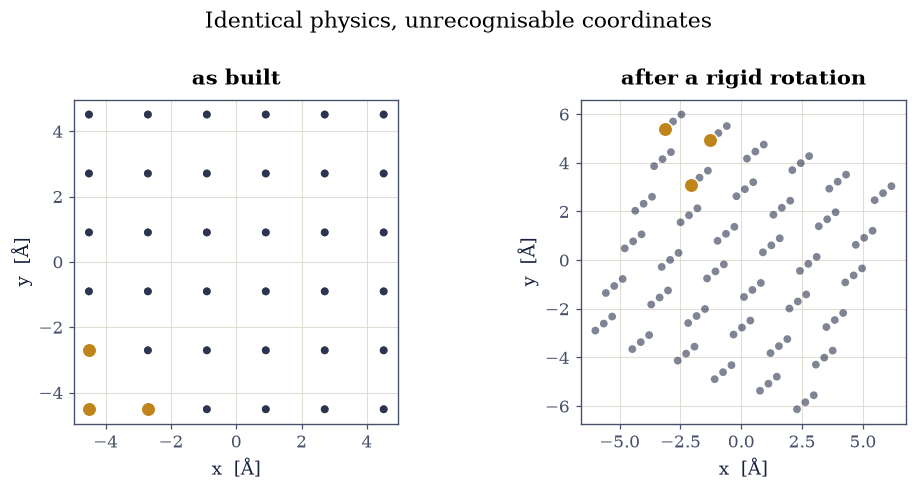

||X - X(translation)|| =   41.491 Å   ( 7.77 × the structure size)
||X - X(rotation)|| =   89.511 Å   (16.76 × the structure size)
||X - X(rotation + relabelling)|| =   80.466 Å   (15.07 × the structure size)
RMS atomic position (the structure's own scale) = 5.339 Å
max change in any pair distance under translation           : 1.78e-15 Å
max change in any pair distance under rotation              : 5.33e-15 Å
max change in any pair distance under rotation + relabelling: 5.33e-15 Å


In [4]:
# (solution hidden on the public site)


### Validation 1 — the coordinates move, the physics does not

Two checks that between them state the whole problem. The coordinate vector must move
by at least the size of the structure under operations that change nothing, and the
set of interatomic distances must not move at all. A model fed coordinates would have
to learn to undo the first; a model fed distances gets the second for free.

In [5]:
validate.check(
    all(v > rms_position for v in moves.values()),
    "every symmetry operation displaces the coordinate vector by more than the whole "
    "size of the structure, so coordinates encode the arbitrary choice of frame and "
    "labelling at least as strongly as they encode the structure",
    ", ".join(f"{k}: {v/rms_position:.2f}×" for k, v in moves.items()),
)
validate.check(
    all(v < 1e-9 for v in pair_shifts.values()),
    "while the multiset of interatomic distances is unchanged to machine precision by "
    "all three, which is why every descriptor that follows is built out of distances "
    "rather than positions",
    f"largest change in any pair distance: {max(pair_shifts.values()):.1e} Å",
)

✓  every symmetry operation displaces the coordinate vector by more than the whole size of the structure, so coordinates encode the arbitrary choice of frame and labelling at least as strongly as they encode the structure   [translation: 7.77×, rotation: 16.76×, rotation + relabelling: 15.07×]
✓  while the multiset of interatomic distances is unchanged to machine precision by all three, which is why every descriptor that follows is built out of distances rather than positions   [largest change in any pair distance: 5.3e-15 Å]


True

---
## Exercise 2 — Radial symmetry functions

Now build the first real descriptor. Equation {eq}`eq-bp-g2` sums a Gaussian over the
neighbours of one atom, so it depends only on distances and only through a sum — the
two properties that buy invariance to all three operations at once.

**Part a)** Implement the cutoff of {eq}`eq-bp-cutoff` and the radial functions of
{eq}`eq-bp-g2`, taking the neighbour distances from the `neighbours` instrument.
**Write this one yourself** — the implementation is the lesson.

**Part b)** Verify invariance numerically. Apply a translation, a rotation, and a
permutation of the neighbour labels to an isolated cluster, and confirm the descriptor
of the central atom is unchanged to machine precision in every case.

**Part c)** Show the descriptor is doing something: plot the radial functions against
distance and compare the descriptor of a bulk atom against one in the surface layer of
a slab, where the missing half-space should show up as missing neighbour density.

relative change in the descriptor under translation : 1.80e-16
relative change in the descriptor under rotation    : 7.33e-17
relative change in the descriptor under permutation : 0.00e+00


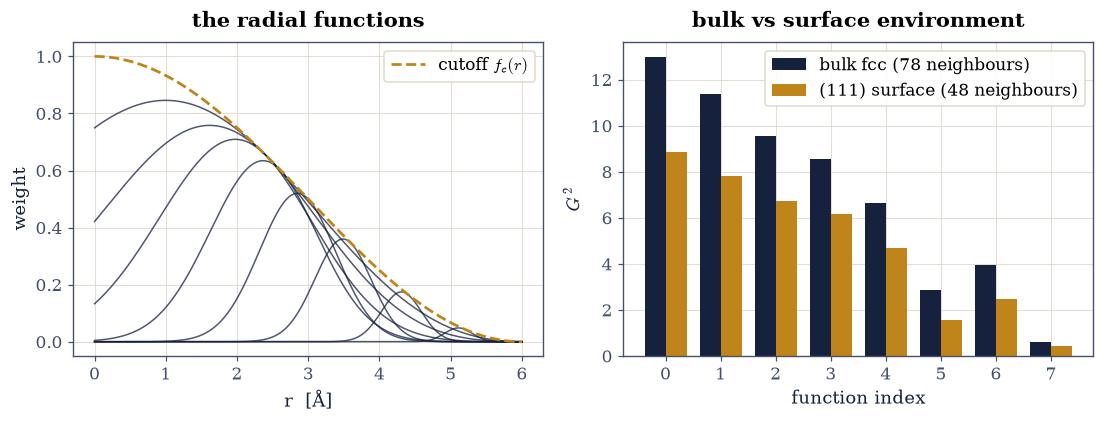

bulk atom: 78 neighbours within 6.0 Å; surface atom: 48
every component drops at the surface; the largest drop leaves 54.7 % of the bulk value


In [6]:
# (solution hidden on the public site)


### Validation 2 — invariant, and not vacuous

Three checks. The descriptor must be unchanged to machine precision by all three
symmetry operations, which is the property it was built for. It must nonetheless
distinguish a bulk atom from a surface one, since a descriptor invariant to everything
would be useless. And the surface values must be *lower* in every component, because
the surface atom is missing neighbours rather than merely rearranged ones.

In [7]:
validate.check(
    all(v < 1e-12 for v in invariance.values()),
    "translation, rotation and relabelling leave the radial descriptor unchanged to "
    "machine precision, so the invariance is exact by construction rather than "
    "approximately learned from data",
    ", ".join(f"{k}: {v:.1e}" for k, v in invariance.items()),
)
validate.check(
    np.linalg.norm(desc_surf - desc_bulk) / np.linalg.norm(desc_bulk) > 0.1,
    "and yet it separates a bulk atom from a surface atom by a wide margin, so the "
    "invariance was not bought by throwing the structural information away",
    f"relative difference {np.linalg.norm(desc_surf-desc_bulk)/np.linalg.norm(desc_bulk):.3f}",
)
validate.check(
    bool(np.all(desc_surf < desc_bulk)),
    "with every component lower at the surface, as it must be when an environment "
    "loses neighbours rather than rearranging the ones it has",
    f"largest surviving fraction {100*surf_drop:.1f} % of the bulk value",
)

✓  translation, rotation and relabelling leave the radial descriptor unchanged to machine precision, so the invariance is exact by construction rather than approximately learned from data   [translation: 1.8e-16, rotation: 7.3e-17, permutation: 0.0e+00]
✓  and yet it separates a bulk atom from a surface atom by a wide margin, so the invariance was not bought by throwing the structural information away   [relative difference 0.310]
✓  with every component lower at the surface, as it must be when an environment loses neighbours rather than rearranging the ones it has   [largest surviving fraction 54.7 % of the bulk value]


True

---
## Exercise 3 — What radial functions cannot see

Face-centred cubic and hexagonal close packed are the two ways of stacking
close-packed planes: `ABCABC` for fcc, `ABAB` for hcp. Both give every atom twelve
nearest neighbours at the same distance. The difference between them is real —
different metals choose different stackings, and the stacking-fault energy between
them is a quantity people compute — but it is subtle, and it is exactly the kind of
thing a descriptor has to be able to see.

**Part a)** Tabulate the neighbour shells of fcc, hcp and bcc at a cutoff of 4 Å,
with all three at the same nearest-neighbour distance. Establish which pairs of phases
share a shell structure and which do not.

**Part b)** Compute the radial descriptor of {eq}`eq-bp-g2` for each phase at that
cutoff and compare them. Predict the outcome from Part a before running it, then
confirm that no choice of $\eta$ and $R_s$ could change it.

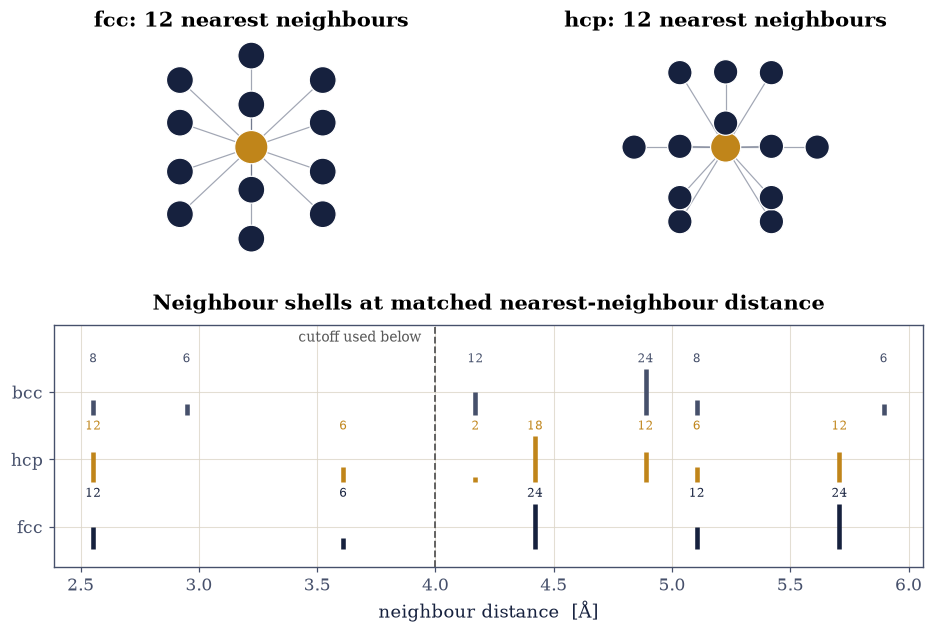

fcc: within 4.0 Å -> 12@2.553 Å, 6@3.610 Å
hcp: within 4.0 Å -> 12@2.553 Å, 6@3.610 Å
bcc: within 4.0 Å -> 8@2.553 Å, 6@2.948 Å

relative difference of the radial descriptors at Rc = 4.0 Å
  fcc vs hcp: 7.98e-16   <- identical to machine precision
  fcc vs bcc: 9.17e-02


In [8]:
# (solution hidden on the public site)


### Validation 3 — a provable blindness

Two checks. The radial descriptors of fcc and hcp must agree to machine precision,
which is a statement not about this parameter set but about every possible one: a
function of the distance multiset cannot separate environments whose distance
multisets are equal. And bcc must be separated comfortably, so that the failure is
specific to the close-packed pair rather than a descriptor that never works.

In [9]:
validate.check(
    fcc_hcp_radial < 1e-12,
    "the radial descriptors of fcc and hcp are identical to machine precision, and no "
    "richer set of η and Rs could change that: inside this cutoff the two phases "
    "present the same multiset of distances, and G2 sees nothing else",
    f"relative difference {fcc_hcp_radial:.1e}",
)
validate.check(
    fcc_bcc_radial > 0.01,
    "while bcc, whose first shell holds eight neighbours rather than twelve, is "
    "separated easily — so the blindness is specific to the two close-packed stackings "
    "and not a descriptor that fails at everything",
    f"relative difference {fcc_bcc_radial:.3f}",
)

✓  the radial descriptors of fcc and hcp are identical to machine precision, and no richer set of η and Rs could change that: inside this cutoff the two phases present the same multiset of distances, and G2 sees nothing else   [relative difference 8.0e-16]
✓  while bcc, whose first shell holds eight neighbours rather than twelve, is separated easily — so the blindness is specific to the two close-packed stackings and not a descriptor that fails at everything   [relative difference 0.092]


True

---
## Exercise 4 — Angles, and a trap in the standard form

If distances cannot separate fcc from hcp, angles must: the twelve nearest neighbours
form a cuboctahedron in fcc and an *anti*cuboctahedron in hcp, the same twelve
distances arranged differently. Equation {eq}`eq-bp-g4` is the standard angular
symmetry function, so applying it should settle the matter.

**Part a)** Compute the first-shell bond-angle distributions of fcc and hcp and
confirm that they genuinely differ. This establishes that there is something for an
angular descriptor to find.

**Part b)** Implement {eq}`eq-bp-g4` and apply it to the two phases at the 4 Å cutoff.
**Write this one yourself** — the implementation is the lesson. Then explain the
result: it is not the one Part a leads you to expect, and the reason is in the formula.

**Part c)** Implement the $G^5$ variant of {eq}`eq-bp-g5`, which differs only by
dropping the factors involving $r_{jk}$, and compare. Then scan the angular sharpness
$\zeta$ and find where the separation appears.

fcc first-shell angles: 24@60°  12@90°  24@120°  6@180°
hcp first-shell angles: 24@60°  12@90°  3@109°  18@120°  6@146°  3@180°


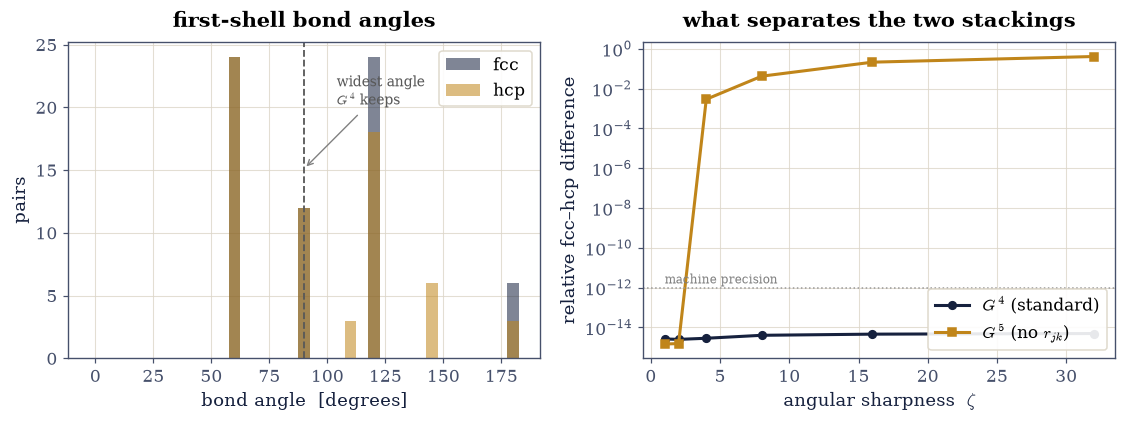


widest angle whose pair survives G4's r_jk cutoff at Rc = 4.0 Å: 90°
G4 fcc-hcp separation, over ζ = [1.0, 2.0, 4.0, 8.0, 16.0, 32.0]:
   2.6e-15  2.5e-15  2.8e-15  4.0e-15  4.6e-15  4.9e-15
G5 fcc-hcp separation:
   1.5e-15  1.5e-15  2.9e-03  4.2e-02  2.1e-01  4.1e-01


In [10]:
# (solution hidden on the public site)


### Validation 4 — the angular functions, and the one that works

Four checks. The bond-angle distributions must genuinely differ, or there would be
nothing for an angular function to find. The standard $G^4$ must nonetheless return
machine zero at every sharpness, because its $r_{jk}$ factors discard the wide-angle
pairs; the explicit statement of that mechanism is that the widest angle it keeps
falls short of where the distributions part company. And $G^5$, differing only by
those factors, must separate the two phases — but only once $\zeta$ is large enough,
since a blurred angular filter averages the difference away.

In [11]:
angle_hist_diff = float(
    np.abs(
        np.histogram(angle_sets["fcc"], bins=bins)[0]
        - np.histogram(angle_sets["hcp"], bins=bins)[0]
    ).sum()
)
validate.check(
    angle_hist_diff > 0,
    "the first-shell bond-angle distributions of fcc and hcp genuinely differ, so an "
    "angular descriptor has something real to detect where a radial one had nothing",
    f"{angle_hist_diff:.0f} pairs fall in different angle bins",
)
validate.check(
    bool(np.all(sep_g4 < 1e-12)),
    "yet the standard G4 returns machine zero at every sharpness ζ: its cutoff on the "
    "neighbour-neighbour distance rjk is a cutoff on angle in disguise, and at this "
    "radius it discards exactly the wide-angle pairs where the two phases differ",
    f"largest G4 separation over the scan: {sep_g4.max():.1e}",
)
validate.check(
    max_angle_kept < 110.0,
    "which the geometry states directly: two neighbours at distance d subtending θ lie "
    "2d sin(θ/2) apart, so the widest angle surviving the rjk cutoff falls below the "
    "range where the fcc and hcp distributions separate",
    f"widest surviving angle {max_angle_kept:.0f}°, while the distributions differ above 100°",
)
validate.check(
    sep_g5[-1] > 1e-3 and sep_g5[0] < 1e-12,
    "and G5, which differs from G4 only by dropping those factors, separates the two "
    "stackings — but only for sharp angular filters: at ζ = 1 the difference is still "
    "machine zero, because a broad filter averages over precisely what distinguishes them",
    f"G5 separation {sep_g5[0]:.1e} at ζ = {ZETA_SCAN[0]:.0f}, "
    f"{sep_g5[-1]:.1e} at ζ = {ZETA_SCAN[-1]:.0f}",
)

✓  the first-shell bond-angle distributions of fcc and hcp genuinely differ, so an angular descriptor has something real to detect where a radial one had nothing   [18 pairs fall in different angle bins]
✓  yet the standard G4 returns machine zero at every sharpness ζ: its cutoff on the neighbour-neighbour distance rjk is a cutoff on angle in disguise, and at this radius it discards exactly the wide-angle pairs where the two phases differ   [largest G4 separation over the scan: 4.9e-15]
✓  which the geometry states directly: two neighbours at distance d subtending θ lie 2d sin(θ/2) apart, so the widest angle surviving the rjk cutoff falls below the range where the fcc and hcp distributions separate   [widest surviving angle 90°, while the distributions differ above 100°]
✓  and G5, which differs from G4 only by dropping those factors, separates the two stackings — but only for sharp angular filters: at ζ = 1 the difference is still machine zero, because a broad filter averages over pre

True

### Why the smooth filters are blind at low ζ

The $\zeta = 1$ result is not a numerical accident but a small theorem. At $\zeta = 1$
the angular sum is, up to constants, $\sum_{j<k} \cos\theta_{jik}$, and for neighbours
all at the same distance that sum is fixed by

```{math}
:label: eq-cos-sum
\sum_{j<k} \cos\theta_{jik}
  = \frac{1}{2}\left[\left\lVert \sum_j \hat{\mathbf r}_j \right\rVert^2 - n\right],
```

with $n$ the number of neighbours. Both the cuboctahedron and the anticuboctahedron
have $\sum_j \hat{\mathbf r}_j = \mathbf 0$ by symmetry and both have $n = 12$, so the
two sums are equal before any structure is looked at. Only the higher moments of the
angular distribution — reached by $\zeta \ge 4$ — carry the difference.

In [12]:
# (solution hidden on the public site)


fcc: n = 12, ||Σ r̂|| = 3.09e-15, Σcos θ = -6.000000, predicted -6.000000
hcp: n = 12, ||Σ r̂|| = 2.96e-15, Σcos θ = -6.000000, predicted -6.000000


In [13]:
validate.close(
    cos_sums["fcc"],
    cos_sums["hcp"],
    "the two stackings have the same sum of neighbour-pair cosines, exactly as "
    "eq-cos-sum requires once both shells are found to have twelve neighbours and a "
    "vanishing sum of unit vectors — which is why no ζ = 1 angular function, however "
    "parametrised, can tell them apart",
    atol=1e-10,
)

✓  the two stackings have the same sum of neighbour-pair cosines, exactly as eq-cos-sum requires once both shells are found to have twelve neighbours and a vanishing sum of unit vectors — which is why no ζ = 1 angular function, however parametrised, can tell them apart   [got -6 vs expected -6 (rtol=1e-06, atol=1e-10)]


True

## Notebook summary

We asked what it takes to hand an atomic structure to a fitting method, and found that
the obvious answer fails immediately: rotating or relabelling a copper crystal moves
its coordinate vector by more than the size of the crystal while leaving every
interatomic distance, and therefore the energy, exactly where it was.

Building the descriptor out of sums over neighbour distances bought all three
invariances by construction, verified here to machine precision, without making the
descriptor vacuous — a surface atom and a bulk atom remain far apart. But invariance is
not the whole requirement. Cut off at 4 Å, fcc and hcp present *identical* multisets of
distances, so their radial descriptors agree to machine precision and no choice of
parameters could do otherwise.

The angular functions that ought to rescue this turned out to have a trap in their
standard form. Two neighbours at distance $d$ subtending an angle $\theta$ lie
$2d\sin(\theta/2)$ apart, so $G^4$'s cutoff on the neighbour–neighbour distance is a
cutoff on angle in disguise: at this radius it keeps nothing wider than about 90° and
discards exactly the wide-angle pairs where the two stackings differ. The $G^5$
variant, identical but for those factors, separates them — and then only for sharp
angular filters, since {eq}`eq-cos-sum` forces the $\zeta = 1$ response of the two
shells to be equal whatever the parametrisation.

The moral is not that symmetry functions are bad. It is that a descriptor's blind
spots are properties of its functional form, they are not always where intuition puts
them, and they can be found by construction rather than discovered later in a model
that quietly cannot represent what it was asked to.

## Outlook

- **Systematic completeness.** SOAP {cite}`bartok2013` reaches the same invariances by
  expanding a smoothed neighbour density in radial functions and spherical harmonics,
  which can be converged by raising the expansion order rather than by adding
  hand-picked functions. The trade is cost and interpretability.
- **Descriptors you have already built.** The Steinhardt order parameter $q_6$ of
  [§2.1](../02-energy-landscapes/lennard-jones-clusters.ipynb) is a descriptor by this definition, invariant to all three operations
  and designed to separate icosahedral from close-packed order — a single-purpose
  ancestor of the vectors built here.
- **From descriptor to potential.** Feeding these vectors to a neural network, one per
  element, and summing the atomic outputs gives a Behler–Parrinello potential
  {cite}`behler2007`. Its accuracy is bounded above by what the descriptor can
  distinguish, which is why this notebook came first.
- **The many-body completeness question.** Two distinct environments can share *all*
  their two- and three-body correlations, so even angular descriptors have degeneracies
  {cite}`pozdnyakov2020`. The fcc/hcp case here is a mild, curable instance.

### References

```{bibliography}
:filter: docname in docnames
```

In [14]:
from ecp.style import footer

footer()

<ECP header: 1690 chars of HTML>